In [1]:
import pandas as pd
import numpy as np
from datamodel import Order, OrderDepth, TradingState, Trade
from main2 import Trader

In [2]:
# Load Data
prices_df = pd.read_excel('../Round 1/data/prices.xlsx')
trades_df = pd.read_excel('../Round 1/data/trades.xlsx')

# Sort data for accurate sequential processing
prices_df.sort_values(by=['day', 'timestamp'], inplace=True)
trades_df.sort_values(by=['day', 'timestamp'], inplace=True)

In [3]:
def create_order_depth(row):
    order_depth = OrderDepth()

    # Populate bids
    for i in range(1, 4):
        bid_price = row.get(f'bid_price_{i}')
        bid_volume = row.get(f'bid_volume_{i}')
        if pd.notna(bid_price) and pd.notna(bid_volume):
            order_depth.buy_orders[int(bid_price)] = int(bid_volume)

    # Populate asks
    for i in range(1, 3+1):
        ask_price = row.get(f'ask_price_{i}')
        ask_volume = row.get(f'ask_volume_{i}')
        if pd.notna(ask_price) and pd.notna(ask_volume):
            order_depth.sell_orders[int(ask_price)] = int(ask_volume)

    return order_depth


In [4]:
trader = Trader()
positions = {product: 0 for product in prices_df['product'].unique()}
trader_data = ""
total_pnl = 0
history_pnl = []

In [5]:
for (day, timestamp), group in prices_df.groupby(['day', 'timestamp']):
    order_depths = {row['product']: create_order_depth(row) for _, row in group.iterrows()}
    listings = {}
    observations = None
    own_trades = {}
    market_trades = {}

    # Construct state for this timestamp
    state = TradingState(
        traderData=trader_data,
        timestamp=timestamp,
        listings=listings,
        order_depths=order_depths,
        own_trades=own_trades,
        market_trades=market_trades,
        position=positions,
        observations=observations
    )

    # Run your trading algorithm
    orders, _, trader_data = trader.run(state)

    # Simulate order execution based on mid-price for simplicity
    for product, order_list in orders.items():
        if not order_list:
            continue

        mid_price = group[group['product'] == product]['mid_price'].iloc[0]
        for order in order_list:
            executed_qty = order.quantity  # Simplified assumption: fully executed
            positions[product] += executed_qty

            # Update realized PnL (simplified mid-price execution)
            total_pnl -= executed_qty * mid_price  # buy (-), sell (+)

    # Record total PnL for each timestamp
    history_pnl.append((day, timestamp, total_pnl))


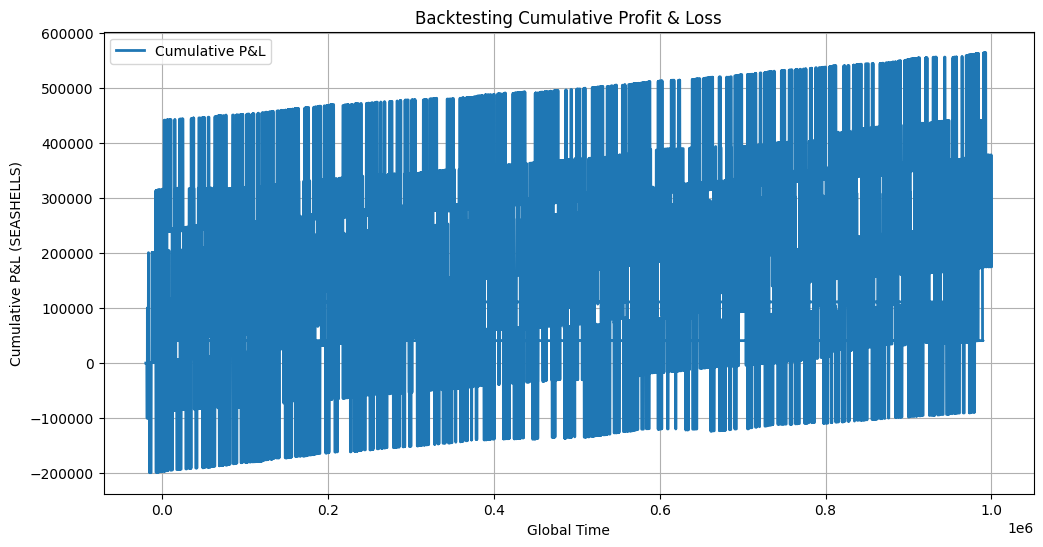

In [6]:
import matplotlib.pyplot as plt

pnl_df = pd.DataFrame(history_pnl, columns=['day', 'timestamp', 'cumulative_pnl'])
pnl_df['global_time'] = pnl_df['day'] * 10000 + pnl_df['timestamp']

plt.figure(figsize=(12, 6))
plt.plot(pnl_df['global_time'], pnl_df['cumulative_pnl'], label='Cumulative P&L', linewidth=2)
plt.xlabel('Global Time')
plt.ylabel('Cumulative P&L (SEASHELLS)')
plt.title('Backtesting Cumulative Profit & Loss')
plt.grid(True)
plt.legend()
plt.show()
